# **Inteligencia Artificial - Clase 2**
## **Visión de Proyecto y Regresión Lineal**

### Objetivos de la Clase:
1. Comprender el pipeline de un proyecto de IA
2. Implementar regresión lineal desde cero con NumPy
3. Usar scikit-learn para regresión lineal
4. Entender la importancia del preprocesamiento
5. Analizar diagnósticos de modelos (residuos, VIF)

---

## 1. El Pipeline de IA

**Completa el siguiente diagrama del pipeline de IA:**

```
[Definición del Problema] -> [Recolección de Datos] -> [EDA y Preprocesamiento]
                                                              |
                                                              v
[Despliegue y Monitoreo] <- [Evaluación y Ajuste] <- [Entrenamiento del Modelo]
```

**Pregunta:** ¿Qué etapas del pipeline vamos a cubrir hoy?

*Respuesta:* _________________________________________________________________

---

## 2. Carga y Exploración de Datos

### 2.1 Importar librerías

In [2]:
# Completa las importaciones necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Completa: Cargar el dataset California Housing
from sklearn.datasets import fetch_california_housing

# Cargar datos
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2.2 Exploración de datos

**Completa el código para explorar los datos:**

In [22]:
# Completa: Mostrar estadísticas descriptivas
print("=== Estadísticas Descriptivas ===")
print(df.describe())


print("\n=== Información del Dataset ===")
df.info()

# Completa: Verificar valores nulos
print("\n=== Valores Nulos ===")
df.isnull().sum()

=== Estadísticas Descriptivas ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956 

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [4]:
for i, col in enumerate(df.columns):
 print(i, col)

0 MedInc
1 HouseAge
2 AveRooms
3 AveBedrms
4 Population
5 AveOccup
6 Latitude
7 Longitude
8 target


### 2.3 Visualización de datos

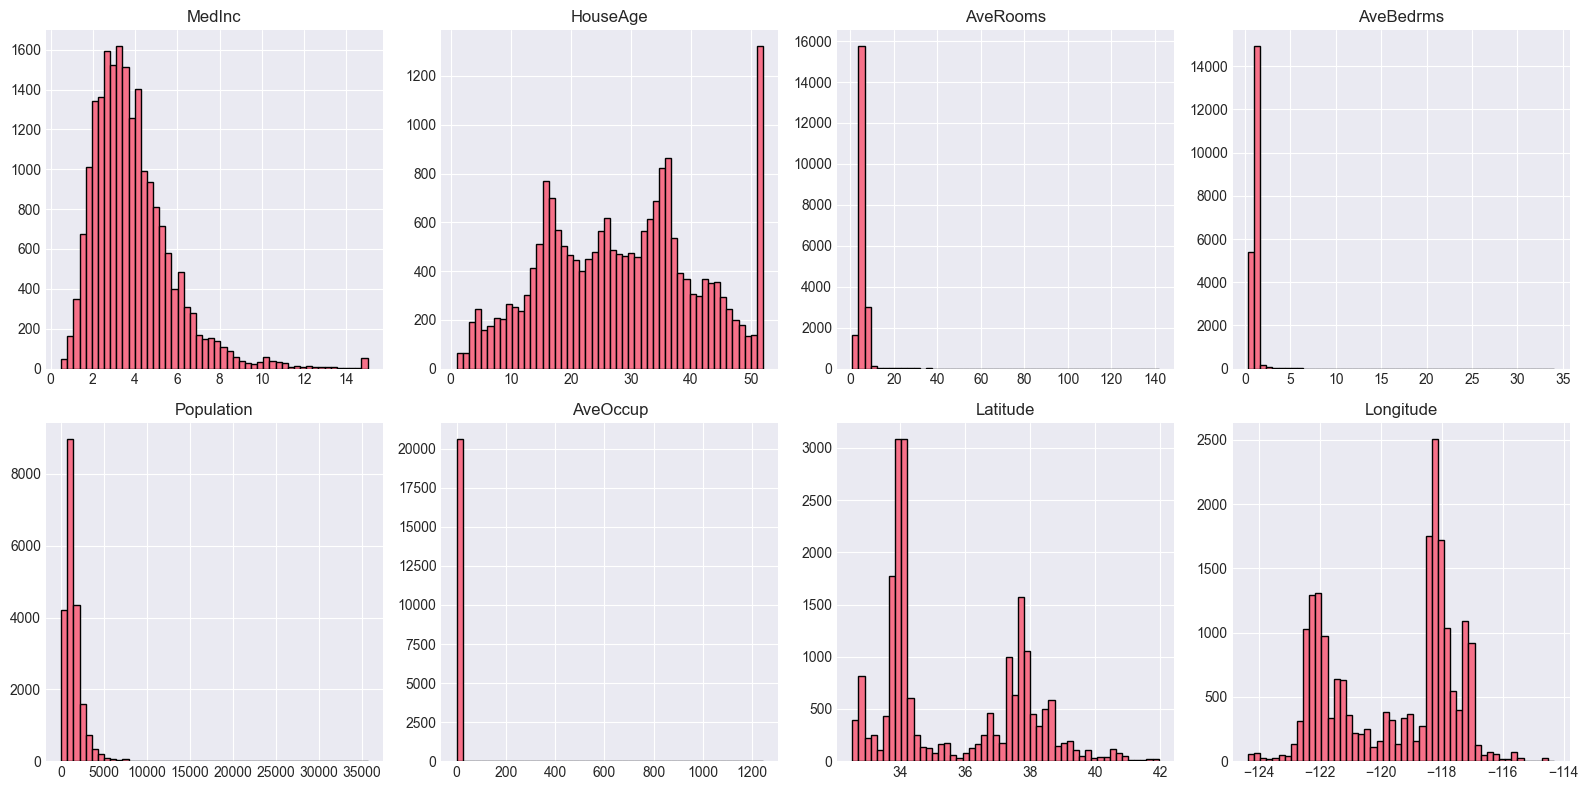

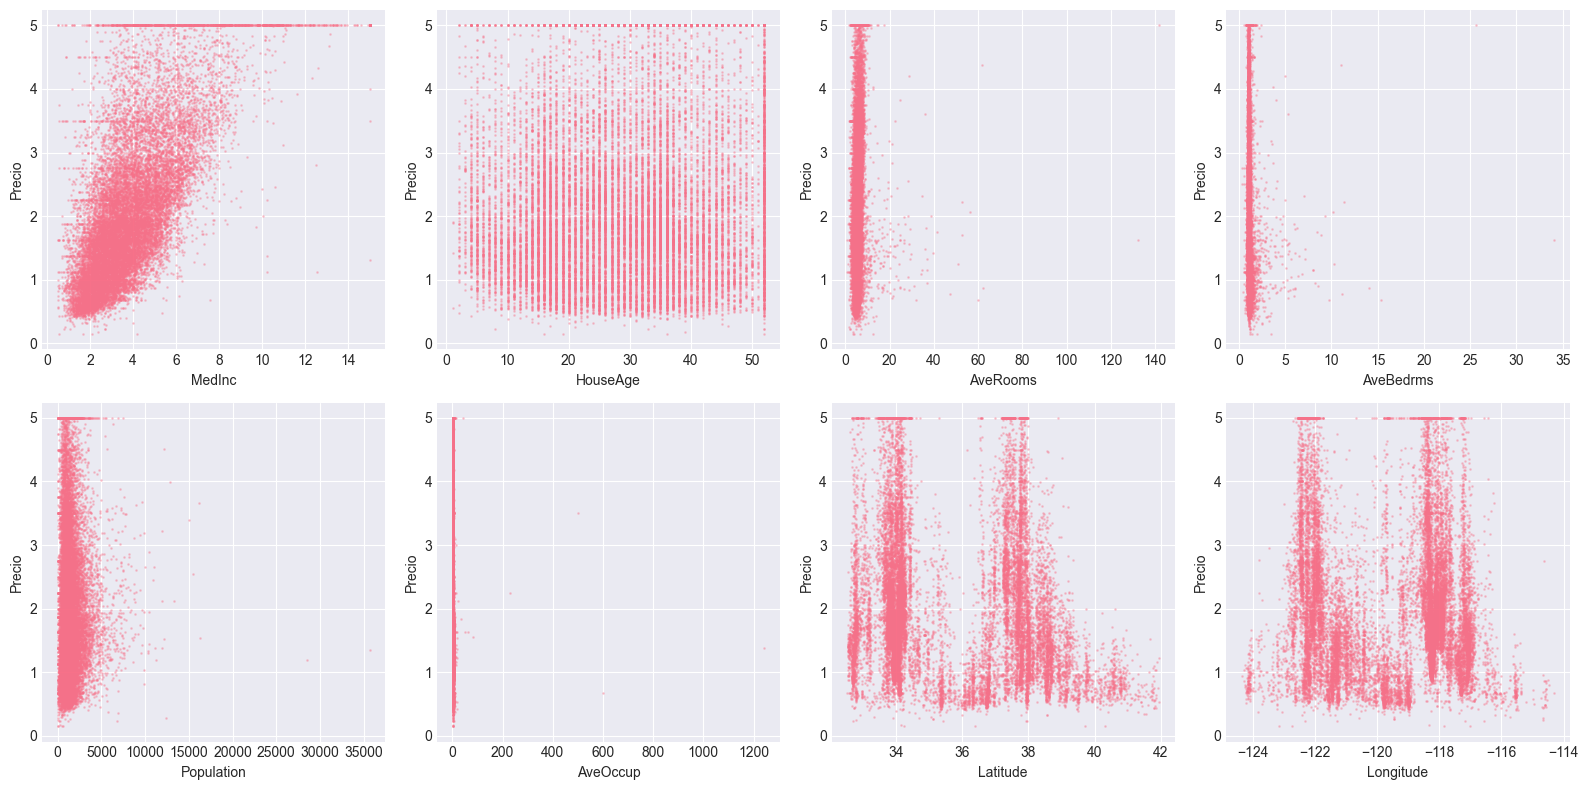

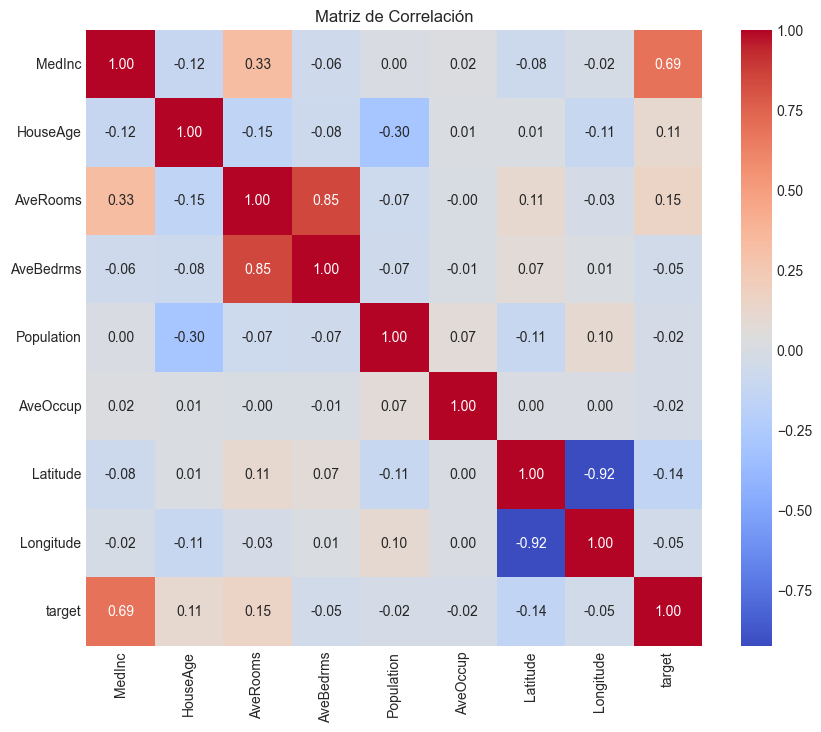

In [5]:
# Completa: Histogramas de todas las variables
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(df.columns):
    if i>=8:  # Solo graficar las primeras 8 columnas
        break
    ax = axes[i//4, i%4]
    # Completa: graficar histograma
    ax.hist(df[col], bins=50, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Completa: Scatter plots vs target
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(df.columns[:-1]):  # Excluir target
    ax = axes[i//4, i%4]
    # Completa: graficar scatter
    ax.scatter(df[col], df['target'], alpha=0.3, s=1)
    ax.set_xlabel(col)
    ax.set_ylabel('Precio')
plt.tight_layout()
plt.show()

# Completa: Matriz de correlación
plt.figure(figsize=(10, 8))
# Completa: heatmap de correlación
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matriz de Correlación')
plt.show()

### 2.4 Preguntas de reflexión

1. ¿Qué variable tiene mayor correlación con el precio?
   *Respuesta:* ___________________________________________________________

2. ¿Qué problema observas en las escalas de las variables?
   *Respuesta:* ___________________________________________________________

3. ¿Crees que la correlación de Population (-0.03) es significativa?
   *Respuesta:* ___________________________________________________________

---

## 3. Regresión Lineal: Teoría y Práctica

### 3.1 Modelo simple con datos sintéticos (Toy Model)

Vamos a generar datos sintéticos para entender el comportamiento de la regresión lineal.

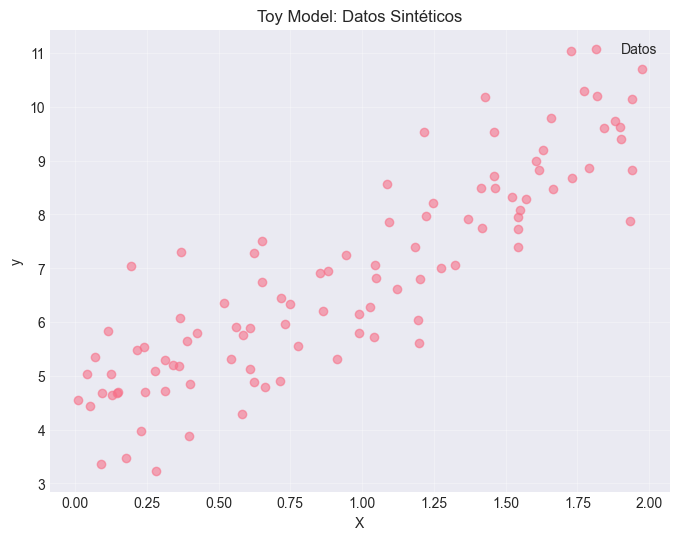

In [6]:
# Generar datos sintéticos (Toy Model)
np.random.seed(42)
N = 100
X_toy = 2 * np.random.rand(N, 1)
y_toy = 4 + 3 * X_toy + np.random.randn(N, 1)

# Visualizar datos
plt.figure(figsize=(8, 6))
plt.scatter(X_toy, y_toy, alpha=0.6, label='Datos')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Toy Model: Datos Sintéticos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Completa: Implementar la Ecuación Normal desde cero**

w0 (intercepto) = 4.2151
w1 (pendiente) = 2.7701
Valor real: w0=4.0, w1=3.0


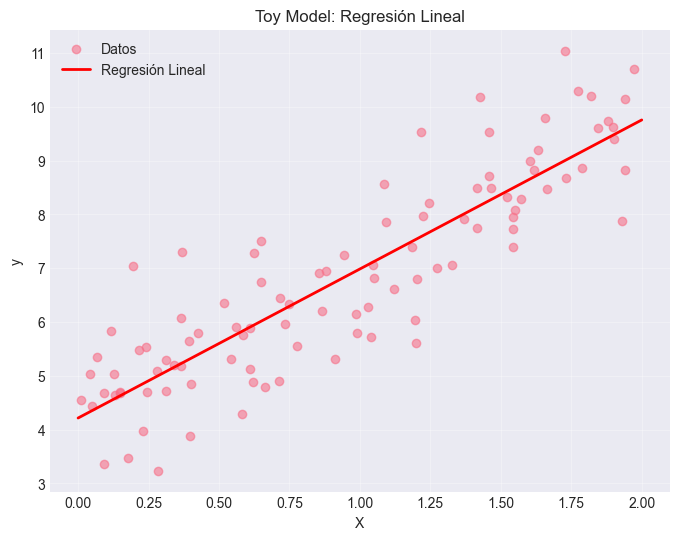

In [7]:
# Completa: Construir la matriz de diseño (incluir bias)
def build_design_matrix(X):
    """Construye la matriz de diseño con una columna de unos para el bias."""
    # Completa
    return np.hstack([np.ones((len(X), 1)), X])

# Ecuación Normal: w = (X^T X)^(-1) X^T y
def normal_equation(X, y):
    """Calcula los parámetros usando la ecuación normal."""
    # Completa
    return np.linalg.pinv(X.T @ X) @ X.T @ y

# Aplicar al toy model
A_toy = build_design_matrix(X_toy)
w_toy = normal_equation(A_toy, y_toy)

print(f"w0 (intercepto) = {w_toy[0,0]:.4f}")
print(f"w1 (pendiente) = {w_toy[1,0]:.4f}")
print(f"Valor real: w0=4.0, w1=3.0")

# Completar: Predecir y graficar
X_pred = np.linspace(0, 2, 100).reshape(-1, 1)
A_pred = build_design_matrix(X_pred)
y_pred = A_pred @ w_toy

plt.figure(figsize=(8, 6))
plt.scatter(X_toy, y_toy, alpha=0.6, label='Datos')
# Completa: graficar la línea de regresión
plt.plot(X_pred, y_pred, 'r-', linewidth=2, label='Regresión Lineal')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Toy Model: Regresión Lineal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.2 Gradiente Descendente desde cero

**Completa la implementación del Gradiente Descendente:**

Iteración 0: Loss = 10.060033
Iteración 100: Loss = 0.417172
Iteración 200: Loss = 0.403745
Iteración 300: Loss = 0.403307
Iteración 400: Loss = 0.403293

Resultados Gradiente Descendente:
w0 = 4.2148
w1 = 2.7704


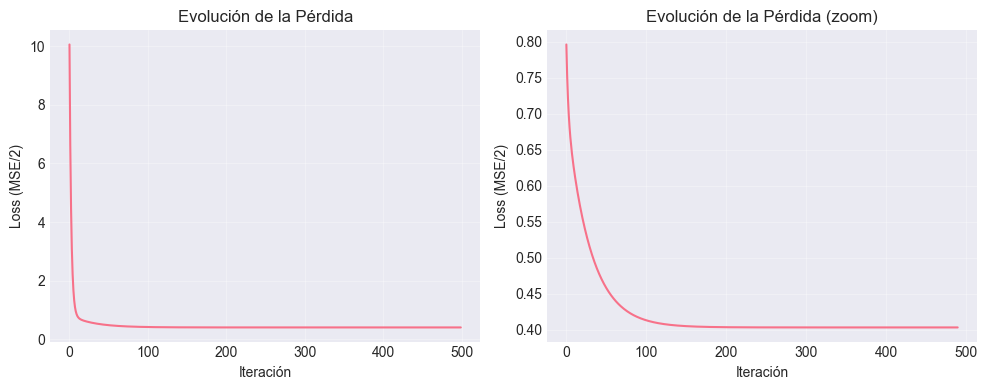

In [8]:
def gradient_descent(X, y, learning_rate=0.1, n_iterations=1000):
    """
    Implementa el algoritmo de gradiente descendente.
    
    Args:
        X: Matriz de diseño (incluye bias)
        y: Vector de valores objetivo
        learning_rate: Tasa de aprendizaje (eta)
        n_iterations: Número de iteraciones
    
    Returns:
        w: Parámetros finales
        loss_history: Historial de la función de costo
    """
    # Inicializar parámetros
    m = len(y)
    w = np.random.randn(X.shape[1], 1)
    loss_history = []
    
    for i in range(n_iterations):
        # Completa: Calcular el gradiente
        # ∇J(w) = (1/m) * X^T (Xw - y)
        gradient = (1/m) * X.T @ (X @ w - y)
        
        # Completa: Actualizar parámetros
        w = w - learning_rate * gradient
        
        # Calcular y guardar la pérdida (MSE)
        loss = np.mean((X @ w - y) ** 2) / 2
        loss_history.append(loss)
        
        if i % 100 == 0:
            print(f"Iteración {i}: Loss = {loss:.6f}")
    
    return w, loss_history

# Aplicar al toy model
w_gd, loss_history = gradient_descent(A_toy, y_toy, learning_rate=0.1, n_iterations=500)

print(f"\nResultados Gradiente Descendente:")
print(f"w0 = {w_gd[0,0]:.4f}")
print(f"w1 = {w_gd[1,0]:.4f}")

# Graficar la evolución de la pérdida
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Iteración')
plt.ylabel('Loss (MSE/2)')
plt.title('Evolución de la Pérdida')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_history[10:])
plt.xlabel('Iteración')
plt.ylabel('Loss (MSE/2)')
plt.title('Evolución de la Pérdida (zoom)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Comparación de métodos

**Completa: Comparar la Ecuación Normal vs Gradiente Descendente**

In [9]:
print("=== Comparación de Métodos ===")
print(f"Ecuación Normal: w0 = {w_toy[0,0]:.6f}, w1 = {w_toy[1,0]:.6f}")
print(f"Gradiente Descendente: w0 = {w_gd[0,0]:.6f}, w1 = {w_gd[1,0]:.6f}")
print(f"Valores reales: w0 = 4.000000, w1 = 3.000000")

# Completar: Calcular diferencias
diff_w0 = abs(w_toy[0,0] - 4.0)
diff_w1 = abs(w_toy[1,0] - 3.0)
print(f"\nError Ecuación Normal: w0: {diff_w0:.6f}, w1: {diff_w1:.6f}")

diff_w0_gd = abs(w_gd[0,0] - 4.0)
diff_w1_gd = abs(w_gd[1,0] - 3.0)
print(f"Error Gradiente Descendente: w0: {diff_w0_gd:.6f}, w1: {diff_w1_gd:.6f}")

=== Comparación de Métodos ===
Ecuación Normal: w0 = 4.215096, w1 = 2.770113
Gradiente Descendente: w0 = 4.214768, w1 = 2.770403
Valores reales: w0 = 4.000000, w1 = 3.000000

Error Ecuación Normal: w0: 0.215096, w1: 0.229887
Error Gradiente Descendente: w0: 0.214768, w1: 0.229597


**Preguntas de reflexión:**

1. ¿Qué método converge más rápido?
   *Respuesta:* ___________________________________________________________

2. ¿Qué sucede si cambiamos la tasa de aprendizaje (learning_rate)?
   *Respuesta:* ___________________________________________________________

---

## 4. Regresión Lineal Multivariada con Scikit-learn

### 4.1 Cargar y preparar datos de Ventas

In [10]:
# Cargar datos de ventas (asegurarse de tener el archivo Ventas.csv)
# Si no está disponible, usaremos el dataset de California Housing
# Para este ejercicio, usaremos una versión simplificada del dataset de ventas

# Crear datos sintéticos de ventas similares al ejemplo
np.random.seed(42)
n_samples = 200
tv = np.random.uniform(0.7, 296.4, n_samples)
radio = np.random.uniform(0, 49.6, n_samples)
newspaper = np.random.uniform(0.3, 114, n_samples)

# Generar ventas con ruido
sales = (2.88 + 0.0466 * tv + 0.179 * radio + 0.00345 * newspaper + 
         np.random.normal(0, 0.5, n_samples))

df_sales = pd.DataFrame({
    'TV': tv,
    'Radio': radio,
    'Newspaper': newspaper,
    'Sales': sales
})

print("Datos de Ventas:")
df_sales.head()
print(f"\nForma: {df_sales.shape}")

Datos de Ventas:

Forma: (200, 4)


**Completa: Preparar X e y y dividir en train/test**

In [11]:
from sklearn.model_selection import train_test_split

# Definir características y objetivo
feature_cols = ['TV', 'Radio', 'Newspaper']

# Completar: Crear X e y
X_sales = df_sales[feature_cols]
y_sales = df_sales['Sales']

# Completar: Dividir en train/test (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X_sales, y_sales, test_size=0.25, random_state=1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (150, 3)
X_test shape: (50, 3)


### 4.2 Entrenar modelo con Scikit-learn

In [12]:
from sklearn.linear_model import LinearRegression

# Completar: Crear y entrenar el modelo
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Completar: Mostrar coeficientes e intercepto
print("Coeficientes:")
for feature, coef in zip(feature_cols, linreg.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercepto: {linreg.intercept_:.4f}")

# Completar: Hacer predicciones
y_pred = linreg.predict(X_test)

Coeficientes:
  TV: 0.0464
  Radio: 0.1768
  Newspaper: 0.0037
Intercepto: 2.9330


### 4.3 Métricas de evaluación

=== Métricas de Evaluación ===
MAE: 0.4265
MSE: 0.2704
RMSE: 0.5200
R²: 0.9867


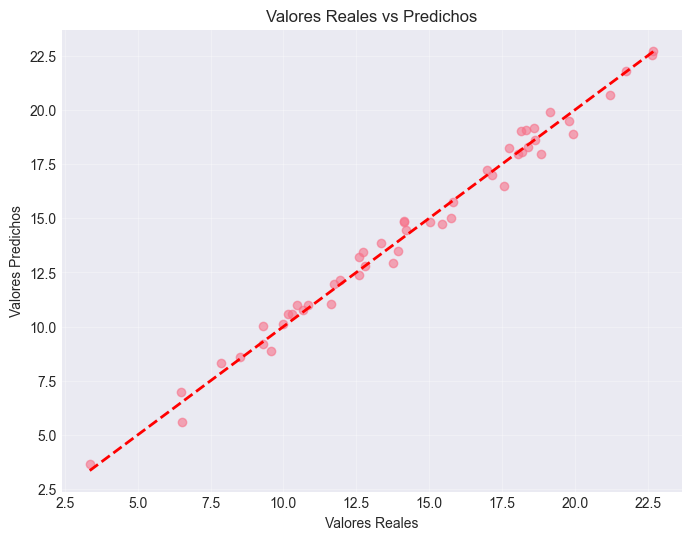

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Completar: Calcular métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = linreg.score(X_test, y_test)  # R² ya viene con el modelo

print("=== Métricas de Evaluación ===")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Graficar valores reales vs predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs Predichos')
plt.grid(True, alpha=0.3)
plt.show()

**Pregunta:** ¿Qué indica el R²? ¿Es un buen modelo?

*Respuesta:* ___________________________________________________________

---

## 5. Selección de Características

**Completa: Entrenar modelo sin Newspaper y comparar RMSE**

In [14]:
# Completar: Modelo sin Newspaper
feature_cols_reduced = ['TV', 'Radio']
X_train_red = X_train[feature_cols_reduced]
X_test_red = X_test[feature_cols_reduced]

linreg_red = LinearRegression()
linreg_red.fit(X_train_red, y_train)

y_pred_red = linreg_red.predict(X_test_red)
rmse_red = np.sqrt(mean_squared_error(y_test, y_pred_red))

print(f"RMSE con todas las variables: {rmse:.4f}")
print(f"RMSE sin Newspaper: {rmse_red:.4f}")

# Completar: Comparar
if rmse_red < rmse:
    print("✓ El RMSE disminuyó. Newspaper no es relevante.")
else:
    print("✗ El RMSE aumentó. Newspaper es relevante.")

RMSE con todas las variables: 0.5200
RMSE sin Newspaper: 0.5700
✗ El RMSE aumentó. Newspaper es relevante.


**Pregunta:** ¿Qué conclusión podemos sacar?

*Respuesta:* ___________________________________________________________

---

## 6. Análisis de Diagnóstico

### 6.1 Análisis de Residuos

**Completa: Calcular y visualizar residuos**

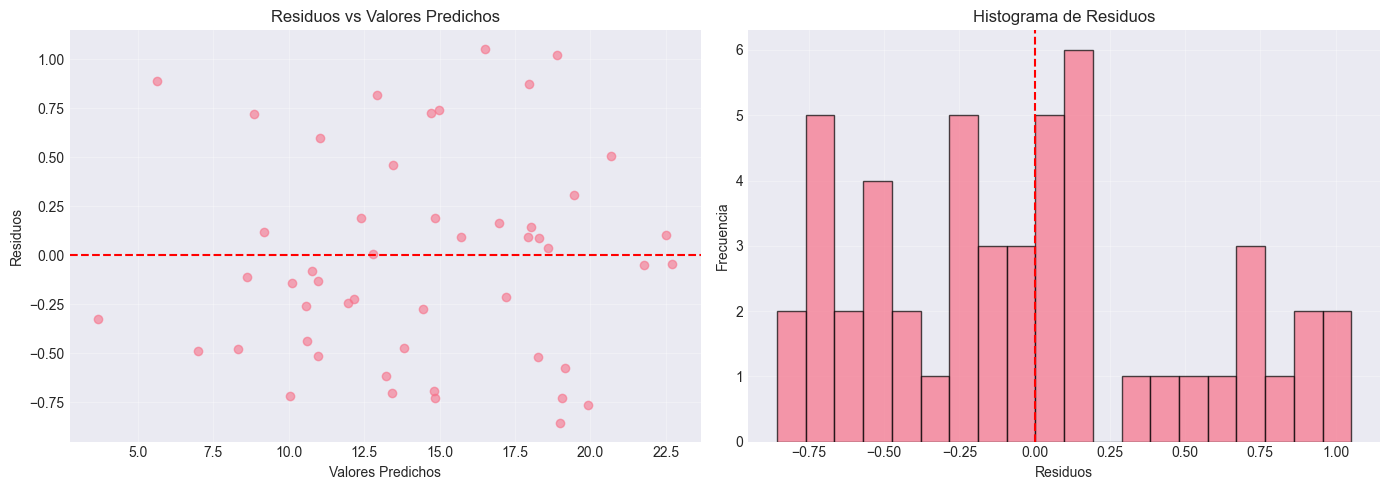

=== Estadísticas de Residuos ===
Media: -0.0285
Desviación estándar: 0.5192
Mínimo: -0.8555
Máximo: 1.0523


In [15]:
# Completar: Calcular residuos
residuos = y_test - y_pred

# Completar: Graficar residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de residuos vs valores predichos
axes[0].scatter(y_pred, residuos, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Predichos')
axes[0].grid(True, alpha=0.3)

# Histograma de residuos
axes[1].hist(residuos, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residuos')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Histograma de Residuos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Completar: Estadísticas de residuos
print("=== Estadísticas de Residuos ===")
print(f"Media: {np.mean(residuos):.4f}")
print(f"Desviación estándar: {np.std(residuos):.4f}")
print(f"Mínimo: {np.min(residuos):.4f}")
print(f"Máximo: {np.max(residuos):.4f}")

**Pregunta:** ¿Los residuos parecen tener media cero y distribución normal?

*Respuesta:* ___________________________________________________________

### 6.2 El Problema de las Escalas

**Completa: Calcular el número de condición**

In [16]:
# Completar: Construir matriz con bias
X_bias = np.c_[np.ones((X_sales.shape[0], 1)), X_sales.values]
cond_number = np.linalg.cond(X_bias.T @ X_bias)

print(f"Número de condición de X^T X: {cond_number:.2e}")

if cond_number > 1e10:
    print("⚠️  Número de condición muy alto. La matriz está mal condicionada.")
    print("   Esto puede causar inestabilidad numérica en la inversión.")
else:
    print("✓ Número de condición aceptable.")

Número de condición de X^T X: 3.45e+05
✓ Número de condición aceptable.


### 6.3 Factor de Inflación de la Varianza (VIF)

**Completa: Calcular VIF para detectar multicolinealidad**

In [17]:
# Instalar statsmodels si no está disponible
!pip install statsmodels -q

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Completar: Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data['Variable'] = feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_sales.values, i) for i in range(X_sales.shape[1])]

print("=== Factor de Inflación de la Varianza (VIF) ===")
print(vif_data)

# Completar: Interpretar VIF
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        print(f"⚠️  {row['Variable']} tiene VIF = {row['VIF']:.2f} > 10. Multicolinealidad severa.")
    elif row['VIF'] > 5:
        print(f"⚠️  {row['Variable']} tiene VIF = {row['VIF']:.2f} > 5. Posible multicolinealidad.")
    else:
        print(f"✓ {row['Variable']} tiene VIF = {row['VIF']:.2f}. Aceptable.")

=== Factor de Inflación de la Varianza (VIF) ===
    Variable       VIF
0         TV  2.639632
1      Radio  2.553569
2  Newspaper  2.497210
✓ TV tiene VIF = 2.64. Aceptable.
✓ Radio tiene VIF = 2.55. Aceptable.
✓ Newspaper tiene VIF = 2.50. Aceptable.


**Pregunta:** ¿Por qué el VIF de algunas variables es alto? ¿Qué implica?

*Respuesta:* ___________________________________________________________

---

## 7. Normalización de Datos

### 7.1 Implementación de normalización

**Completa: Normalizar los datos**

In [18]:
from sklearn.preprocessing import StandardScaler

# Completar: Crear y ajustar el scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sales)

# Verificar estadísticas después de la normalización
print("=== Datos Normalizados ===")
print(f"Media de TV: {np.mean(X_scaled[:, 0]):.10f}")
print(f"Desviación estándar de TV: {np.std(X_scaled[:, 0]):.10f}")
print(f"Media de Radio: {np.mean(X_scaled[:, 1]):.10f}")
print(f"Media de Newspaper: {np.mean(X_scaled[:, 2]):.10f}")

=== Datos Normalizados ===
Media de TV: 0.0000000000
Desviación estándar de TV: 1.0000000000
Media de Radio: -0.0000000000
Media de Newspaper: 0.0000000000


### 7.2 Modelo con datos normalizados

**Completa: Entrenar modelo con datos normalizados**

In [19]:
# Completar: Dividir en train/test con datos normalizados
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y_sales, test_size=0.25, random_state=1
)

# Entrenar modelo
linreg_scaled = LinearRegression()
linreg_scaled.fit(X_train_scaled, y_train)

# Completar: Mostrar coeficientes
print("=== Coeficientes con Datos Normalizados ===")
for feature, coef in zip(feature_cols, linreg_scaled.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercepto: {linreg_scaled.intercept_:.4f}")

# Comparar importancia de variables
print("\n=== Importancia Relativa (valores absolutos) ===")
for feature, coef in zip(feature_cols, linreg_scaled.coef_):
    print(f"  {feature}: {abs(coef):.4f}")

=== Coeficientes con Datos Normalizados ===
  TV: 4.0331
  Radio: 2.5633
  Newspaper: 0.1275
Intercepto: 14.2428

=== Importancia Relativa (valores absolutos) ===
  TV: 4.0331
  Radio: 2.5633
  Newspaper: 0.1275


### 7.3 Comparación de pesos

**Completa: Comparar pesos antes y después de normalizar**

In [20]:
print("=== Comparación de Pesos ===")
print("Variable  |  Sin normalizar  |  Normalizada  |  Cambio")
print("-" * 60)
for i, feature in enumerate(feature_cols):
    coef_original = linreg.coef_[i]
    coef_scaled = linreg_scaled.coef_[i]
    print(f"{feature:9} | {coef_original:14.4f} | {coef_scaled:12.4f} | {coef_scaled/coef_original:6.2f}x")

=== Comparación de Pesos ===
Variable  |  Sin normalizar  |  Normalizada  |  Cambio
------------------------------------------------------------
TV        |         0.0464 |       4.0331 |  86.98x
Radio     |         0.1768 |       2.5633 |  14.50x
Newspaper |         0.0037 |       0.1275 |  34.85x


**Pregunta de reflexión:**

¿Qué variable es más importante según los pesos normalizados?

*Respuesta:* ___________________________________________________________

---

## 8. Resumen y Conclusiones

### 8.1 Lo que aprendimos hoy:

1. **Pipeline de IA:** Etapas de un proyecto, desde la definición hasta el despliegue
2. **Regresión Lineal:** Modelo, función de costo, derivación de la ecuación normal
3. **Métodos de Optimización:** Ecuación Normal vs Gradiente Descendente vs SGD
4. **Implementación:** Desde cero con NumPy y con Scikit-learn
5. **Evaluación:** MAE, MSE, RMSE, R²
6. **Diagnóstico:** Residuos, número de condición, VIF
7. **Preprocesamiento:** Normalización como solución a problemas de escala

### 8.2 Conceptos clave:

- **Ecuación Normal:** Solución directa pero costosa para grandes datasets
- **Gradiente Descendente:** Iterativo, eficiente para grandes volúmenes
- **MLE:** La regresión lineal minimiza MSE bajo ruido Gaussiano
- **Número de Condición (κ):** Medida de estabilidad numérica
- **VIF:** Detección de multicolinealidad
- **Normalización:** Crucial para interpretabilidad y estabilidad

### 8.3 Para la próxima clase:

- Modelos Regularizados (Ridge, Lasso, ElasticNet)
- Selección de características automática
- Validación cruzada

---

## 9. Ejercicio Final: Pipeline Completo

**Completa: Implementar el pipeline completo para el problema de ventas**

In [21]:
def pipeline_completo(df, feature_cols, target_col, test_size=0.25, random_state=1):
    """
    Implementa el pipeline completo de regresión lineal con diagnóstico.
    
    Args:
        df: DataFrame con los datos
        feature_cols: Lista de columnas de características
        target_col: Nombre de la columna objetivo
        test_size: Proporción de test
        random_state: Semilla para reproducibilidad
    
    Returns:
        dict: Diccionario con resultados del pipeline
    """
    # Completar: Preparar datos
    X = df[feature_cols]
    y = df[target_col]
    
    # Completar: Dividir train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Completar: Escalar datos
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Completar: Entrenar modelo
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    # Completar: Predecir
    y_pred = model.predict(X_test_scaled)
    
    # Completar: Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = model.score(X_test_scaled, y_test)
    
    # Completar: Análisis de residuos
    residuos = y_test - y_pred
    
    # Completar: VIF
    vif_data = pd.DataFrame()
    vif_data['Variable'] = feature_cols
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    # Resultados
    resultados = {
        'model': model,
        'scaler': scaler,
        'coeficientes': dict(zip(feature_cols, model.coef_)),
        'intercepto': model.intercept_,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'residuos': residuos,
        'vif': vif_data
    }
    
    return resultados

# Ejecutar el pipeline
resultados = pipeline_completo(df_sales, feature_cols, 'Sales')

print("=== Resultados del Pipeline ===")
print(f"RMSE: {resultados['rmse']:.4f}")
print(f"R²: {resultados['r2']:.4f}")
print("\nCoeficientes:")
for var, coef in resultados['coeficientes'].items():
    print(f"  {var}: {coef:.4f}")
print(f"Intercepto: {resultados['intercepto']:.4f}")
print("\nVIF:")
print(resultados['vif'])

=== Resultados del Pipeline ===
RMSE: 0.5200
R²: 0.9867

Coeficientes:
  TV: 4.1161
  Radio: 2.5595
  Newspaper: 0.1253
Intercepto: 14.1908

VIF:
    Variable       VIF
0         TV  2.639632
1      Radio  2.553569
2  Newspaper  2.497210


**Preguntas de reflexión final:**

1. ¿Cómo afecta la normalización a la interpretabilidad de los coeficientes?
   *Respuesta:* ___________________________________________________________

2. ¿Qué ventaja tiene usar Gradiente Descendente sobre la Ecuación Normal para datasets grandes?
   *Respuesta:* ___________________________________________________________

3. ¿Qué indica un VIF alto? ¿Cómo se puede solucionar?
   *Respuesta:* ___________________________________________________________

4. ¿Qué métrica es más útil para comunicar el error a un cliente no técnico? ¿Por qué?
   *Respuesta:* ___________________________________________________________

